<table style="width:100%;font-size:11pt">
        <tr style="width:100%;font-size:11pt">
            <td style="border: 1px #0098cd solid; background-color:#E6F4F9; color:#0098CD; width:35%"><center>Asignatura</center>
            </td>
            <td style="border: 1px #0098cd solid; background-color:#E6F4F9; color:#0098CD"><center>Datos del alumno</center>
            </td>
            <td style="border: 1px #0098cd solid; background-color:#E6F4F9; color:#0098CD; width:10%"><center>Fecha</center>
            </td>
        </tr>
        <tr style="width:100%;font-size:11pt">
            <td rowspan="2" style="border: 1px #0098cd solid"><center><b>Técnicas Multivariantes y Machine Learning</b></center>
            </td>
            <td style="border: 1px #0098cd solid; text-align:left">Apellidos: Blanco Álvarez</td>
            <td rowspan="2" style="border: 1px #0098cd solid"><center></center>
            </td>
        </tr>
        <tr>
            <td style="border: 1px #0098cd solid; text-align:left">Nombres: Javier
            </td>
        </tr>
            <tr style="width:100%;font-size:11pt">
            <td style="border: 1px #0098cd solid; background-color:#E6F4F9; color:#0098CD"><center>Actividad</center>
            </td>
            <td colspan="2" style="border: 1px #0098cd solid; text-align:left">Actividad: Resolver un problema de clasificación
            </td>
        </tr>    
</table>

# Resolución de un problema de Clasificación
## Técnicas Multivariantes y Machine Learning
### Máster Universitario de Ingeniería matemática y computación
#### Cuatrimestre III
**Autor:** *Javier Blanco*
Febrero, 2025

## Objetivos
* Resolver un problema de clasificación aplicando los modelos basados en árboles de decisión y técnicas de ensamble.
* Evaluar la importancia de las variables para distintos modelos de clasificación
* Comparar los resultados obtenidos entre distintas técnicas

## Descripción del problema
F@rmaTec dispone de información sobre la clasificación de medicamentos según la información general de unos pacientes y sus diagnósticos. Se necesita un modelo de aprendizaje automático para predecir el resultado del tipo de fármaco que podría ser adecuado para el paciente. 
El cunjunto de datos de partida dispone de la siguiente información:

![alt text](image.png)



## Solución

### Importando Librerías y conjunto de datos

In [49]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
cm = plt.colormaps.get_cmap('tab10')
%matplotlib inline

In [50]:
data_set_raw = pd.read_excel('ingmaco04_act3_drugs.xlsx')
data_set_raw.head(3)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25355.0,drugY
1,47,M,LOW,HIGH,13093.0,drugC
2,47,M,LOW,HIGH,10114.0,drugC


### 1) Análisis exploratorio: Descripción del conjunto de datos

Observamos primeramente los tipos de datos involucrados

In [51]:
data_set_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


* Data set conformado por 200 registros y 6 atributos
* Ratio de sodio a potacio (`Na_to_K`) -> Flotante
* Edad (`Age`) -> Entero
* Presión sanguínea (`BP`), Nivel de Colesterol (`Cholesterol`), Sexo (`Sex`) y Fármaco (`Drug`) -> tipo objeto

Para facilitar el manejo de los datos modificaremos el nombre de la variable `Cholesterol` a `Chol`, verificamos valores perdidos o faltantes y aplicamos estadística descriptiva a las variables cuantitativas (`Age` y `Na_to_K`)

In [52]:
data_set = data_set_raw.copy()
data_set = data_set.rename(columns={'Cholesterol':'Chol'})
print(data_set.columns)
nan_values = {c:0 if data_set[c].isna().value_counts else 1 for c in data_set.columns}
print(f'Valores perdidos o faltantes por columna: {nan_values}')
data_set.describe()

Index(['Age', 'Sex', 'BP', 'Chol', 'Na_to_K', 'Drug'], dtype='object')
Valores perdidos o faltantes por columna: {'Age': 0, 'Sex': 0, 'BP': 0, 'Chol': 0, 'Na_to_K': 0, 'Drug': 0}


,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,14901.706900
std,16.544315,8322.843139
min,15.000000,7.340000
25%,31.000000,10053.000000
50%,45.000000,13110.000000
75%,58.000000,19204.500000
max,74.000000,38247.000000


Podemos visualizar los datos cargados mediante diagrama de barras

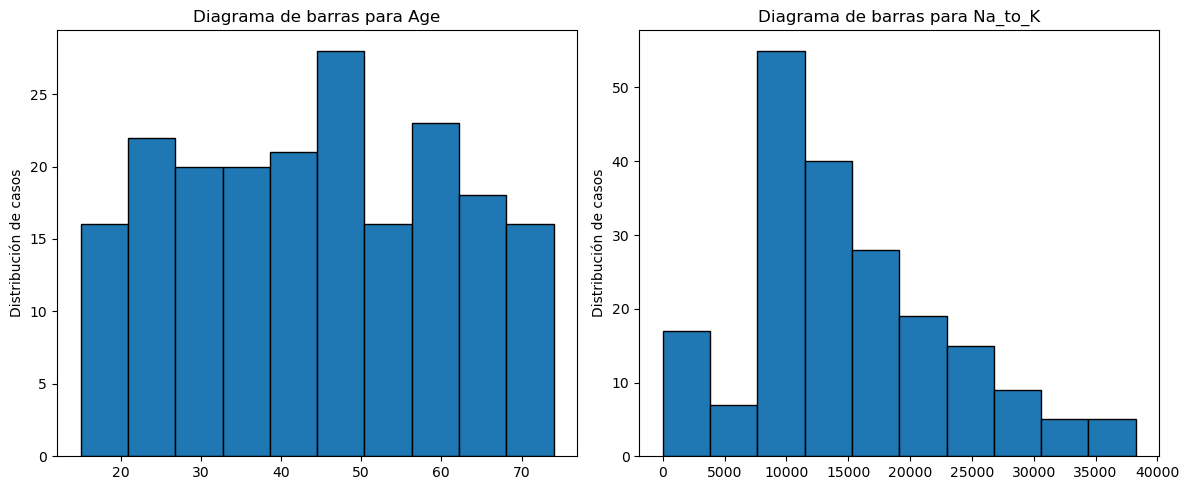

In [53]:
#Variables cuantitativas
plt.figure(figsize = (12, 5))
num_columns = data_set[['Age', 'Na_to_K']].columns
i = 1
for c in num_columns:
    plt.subplot(1,2,i)
    data_set[c].plot(kind='hist', colormap=cm, edgecolor='black')
    plt.ylabel('Distribución de casos')
    plt.title(f'Diagrama de barras para {c}')
    i = i+1
plt.tight_layout()

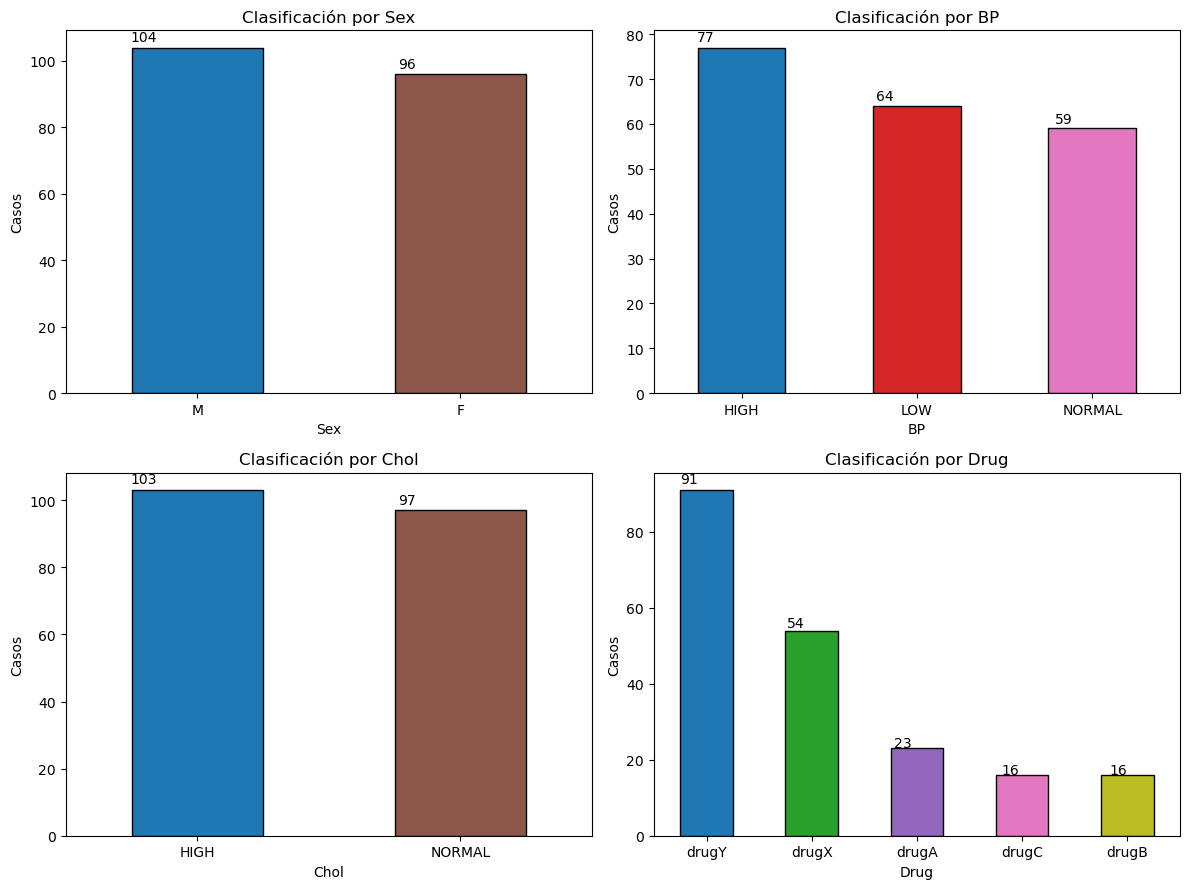

In [54]:
#Variables cualitativas
plt.figure(figsize = (12, 9))
cat_columns = data_set.columns.drop(['Age', 'Na_to_K'])
k = 1
for i, c in enumerate(cat_columns):
    v_counts = data_set[c].value_counts()
    num_categories = len(v_counts)
    colors = [cm(j / num_categories) for j in range(num_categories)]
    plt.subplot(2,2, k)
    ax = v_counts.plot(kind='bar', color=colors, edgecolor='black')
    plt.xlabel(c)
    plt.xticks(rotation=0)
    plt.ylabel('Casos')
    plt.title(f'Clasificación por {c}')
    for p in ax.patches:
        ax.annotate(str(p.get_height()), (p.get_x() * 1.02, p.get_height() * 1.02))
    k = k+1
plt.tight_layout()


#### Observaciones

* El conjunto de datos está conformado por 200 observaciones y 6 atributos; 2 de ellos cuantitativos (Edad y Ratio de Sodio a Potasio) y 4 categóricos (Sexo, tipo de droga, Nivel de colésterol y presión sanguínea). El conjunto datos carece de valores perdidos o faltantes (NAN's).

* La edad de los 200 individuos se encuentra entre los 15 y 74 años, de los cuales 104 son hombres y 96 mujeres. 103 personas reportaron un nivel de colesterol alto (HIGH), en contraparte de los 97 restantes mantienen el colesterol normal (NORMAL). En el caso de la presión en sangre, 59 de los 200 individuos reportaron una presión normal (NORMAL), mientras que 77 y 64 presiones altas (HIGH) y bajas (LOW) respectivamente. 

* En el caso de la variable de ratio de sodio a potacio (`Na_to_K`), convendría normalizar los datos ya que poseen una desviación estándar de `8322.84`. Aunque no es necesario si utilizamos Árboles de Decisión y técnicas de Ensemble. 

* Se recomienda además, tranformar los tipos de las variables categóricos descriptoras de 'string' a tipo 'integer' mediante algunas asociaciones y limpiando el valor de la variable target (Drug):

-Sex  --> Male: 0, Female: 1
-BP   --> Low: 0, Normal: 1, High: 2
-Chol --> Normal: 0, High: 1
-Drug --> DrugA: A, DrugB: B, DrugC: C, DrugX: X, DrugY: Y, 

* Se evidencia un claro **desbalance** en las clases de la variable target. Se recomienda aplicar alguna ténica de *oversampling*
* Para facilitar la visualización de los nodos de los árboles, se han dividido los datos de `Na_to_K` por 1000

#### Aplicando transformación de datos

In [55]:
# Normalizacón de Na_to_K y fijando tipo integer en Age
data_set['Na_to_K'] = data_set['Na_to_K'].apply(lambda x: x / 1000)
data_set = data_set.rename(columns={'Na_to_K':'Na_to_K*1000'})
data_set['Age'] = data_set['Age'].astype(int)
# Sustitución de valores
data_set['Sex'] = data_set['Sex'].apply(lambda x: 1 if x == 'F' else 0)
data_set['BP'] = data_set['BP'].apply(lambda x: 0 if x == 'LOW' else (1 if x == 'NORMAL' else 2)) 
data_set['Chol'] = data_set['Chol'].apply(lambda x: 0 if x == 'NORMAL' else 1)
# Mapeo de drug
drug_mapping = {'drugA': 'A', 'drugB': 'B', 'drugC': 'C', 'drugX': 'X', 'drugY': 'Y'}
data_set['Drug'] = data_set['Drug'].map(drug_mapping)
# Ordenando posición de variables (cuantitativas por un lado y categóricas por otro)
data_set = data_set.iloc[:, [0, 4, 1, 2, 3, 5]]
data_set.head(3)

,Age,Na_to_K*1000,Sex,BP,Chol,Drug
0,23,25.355,1,2,1,Y
1,47,13.093,0,0,1,C
2,47,10.114,0,0,1,C


### 2) Datos de entrenamiento y validación

In [56]:
# Oversampling para incrementar las variables minoritaria en Drugs
smote = SMOTE(random_state=142)
X = np.array(data_set.drop(columns='Drug'))
y = np.array(data_set['Drug'])
X, y = smote.fit_resample(X, y)
# Formateando el array para una mejor visualización de los árboles
for i, dtype in zip([0, 2, 3, 4], [int, int, int, int]):
    X[:, i] = X[:, i].astype(dtype)
X[:, 1] = np.round(X[:, 1], 3)
X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.75, random_state=142, shuffle=True)
print(np.shape(X_train), np.shape(y_train))
# X_train

(341, 5) (341,)


#### Observaciones
* La variable `Drug` se fija como target (`variable de respuesta`)
* Se ha dividido el conjunto de entrenamiento y validación en 75%-25% y semilla de 142. 
* Se ha aplicado *oversampling* sobre la variable Drug minoritaria para garantizar el balance en los datos.
* El conjunto da datos ha pasado de 200 registros a 341.

### 3) Clasificación con Árboles de Decisión
* **Con valores por defecto**

In [57]:
# Árbol de decisión por defecto
dtcl = DecisionTreeClassifier(random_state=142)
model_tree1 = dtcl.fit(X_train, y_train)
y_pred = model_tree1.predict(X_val)
params = model_tree1.get_params()
accuracy_dt = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy_dt}")

Accuracy: 0.9298245614035088


* **Con nivel de profundidad máximo permitido es tres (`max_depth = 3`)**

Accuracy: 0.8771929824561403


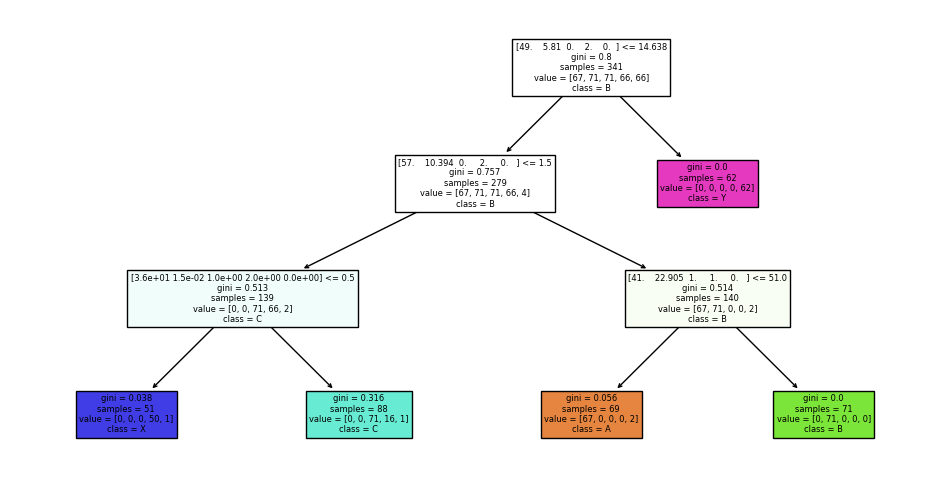

In [58]:
# Árbol con max_depth = 3
dtcl2 = DecisionTreeClassifier(max_depth=3, random_state=142)
model_tree2 = dtcl2.fit(X_train, y_train)
y_pred = model_tree2.predict(X_val)
accuracy_dt2 = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy_dt2}")
# Visualización del árbol generado 
plt.figure(figsize=(12, 6))
plot_tree(model_tree2, filled=True, feature_names=X_train, class_names=['A', 'B', 'C', 'X', 'Y'])
plt.show()

* **Con mínimo número de observaciones que debe contener cada nodo hoja es cinco (`min_samples_leaf=5`)**

Accuracy: 0.8771929824561403


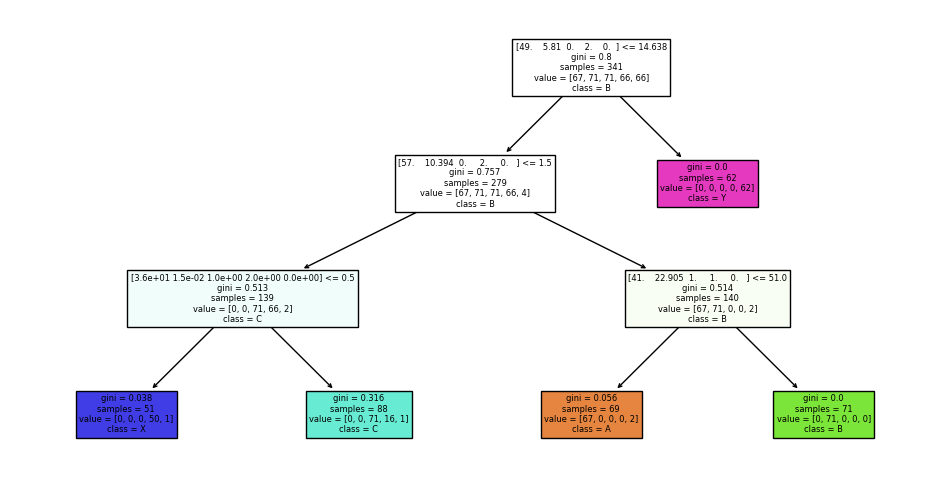

In [59]:
# Árbol con max_depth=3 y min_samples_leaf=5 
dtcl3 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=142)
model_tree3 = dtcl3.fit(X_train, y_train)
y_pred = model_tree3.predict(X_val)
accuracy_dt3 = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy_dt3}")
plt.figure(figsize=(12, 6))
plot_tree(model_tree3, filled=True, feature_names=X_train, class_names=['A', 'B', 'C', 'X', 'Y'])
plt.show()

#### Observaciones
* Con valores por defecto en el clasificador obtenemos un Accuracy de 0.929, mientras que con max_depth = 3, la métrica disminuye hasta 0.877. El accuracy se mantiene en 0.877 tras establecer un min_samples_leaf=5

### 4) Modelos de Ensamble

Para esta parte aplicamos cuatro técnicas de ensamble: Bagging, Pasting, Random Forest y Gradient Boosting. Los enfoques Bagging y Pasting utilizan BaggingClassifier con un modelo de árbol de decisión con valores por defecto con bootstrap=True para Bagging y False para Pasting. El método Random Forest utiliza RandomForestClassifier, que construye múltiples árboles de decisión con complejidad controlada (max_leaf_nodes=4). Finalmente, la técnica Gradient Boosting utiliza GradientBoostingClassifier para mejorar secuencialmente el rendimiento del modelo mientras minimiza los errores de iteraciones anteriores.

In [60]:
# Bagging Ensamble
bgcl = BaggingClassifier(model_tree1, bootstrap=True, random_state=142)
model_tree_bg = bgcl.fit(X_train, y_train)
y_predict_bg = model_tree_bg.predict(X_val)
accuracy_bg = accuracy_score(y_val,y_predict_bg)
# Pasting Ensamble
ptcl = BaggingClassifier(model_tree1, bootstrap=False, random_state=142)
model_tree_pt = ptcl.fit(X_train, y_train)
y_predict_pt = model_tree_pt.predict(X_val)
accuracy_pt = accuracy_score(y_val,y_predict_pt)
# Random Forest Ensamble
rndclf = RandomForestClassifier(max_leaf_nodes = 4, random_state = 142)
model_tree_rf = rndclf.fit(X_train, y_train)
y_predict_rf = rndclf.predict(X_val)
accuracy_rf = accuracy_score(y_val,y_predict_rf)
# Gradient Boosting Ensamble
gdclf = GradientBoostingClassifier(random_state = 142)
model_tree_gd = gdclf.fit(X_train, y_train)
y_predict_gd = gdclf.predict(X_val)
accuracy_gd = accuracy_score(y_val,y_predict_gd)

In [61]:
pd.DataFrame({'Decision Tree': accuracy_dt3,
              'Bagging': accuracy_bg,
              'Pasting':accuracy_pt,
              'Random Forest': accuracy_rf,
              'Gradient Boost': accuracy_gd}, index=['Accuracy'])

,Decision Tree,Bagging,Pasting,Random Forest,Gradient Boost
Accuracy,0.877193,0.929825,0.938596,0.885965,0.95614


#### Observaciones
* Bagging y Pasting son eficaces para reducir la varianza en el modelo base (árbol de decisión). Sin embargo, los resultados tan cercanos indican que el conjunto de datos o la configuración del modelo podrían no beneficiarse significativamente de la diferencia entre Bagging y Pasting.
* La menor precisión para Random Forest podría deberse a la restricción de max_leaf_nodes=4, que limita la profundidad y la complejidad de los árboles del bosque aleatorio. Esto podría provocar un ajuste insuficiente, ya que el modelo podría no capturar suficientes patrones en los datos.
* Se observa una mejora en la precisión de Gradient Boost, esto puede deberse que usa prámetros por defecto, especialmente el learning rate.
* Convendría aplicar técnicas de Afinamiento de Hiperparámetros para incrementar la precisión en la predición de la mejor droga para los pacientes estudiados. 

### 5) Importancia de las variables

Se procede entonces a visualizar y comparar los puntajes de importancia de las características para tres modelos diferentes: árboles de decisión, Random Forest y Gradient Boosting. La importancia de las características cuantifica la contribución de cada una a las predicciones del modelo, proporcionando información sobre qué características son más influyentes. La visualización final resalta cómo los diferentes modelos priorizan las características, proporcionando una perspectiva comparativa sobre sus procesos de toma de decisiones. Este análisis es particularmente útil para comprender el comportamiento del modelo e identificar factores clave en el conjunto de datos.

(-1.0, 5.0)

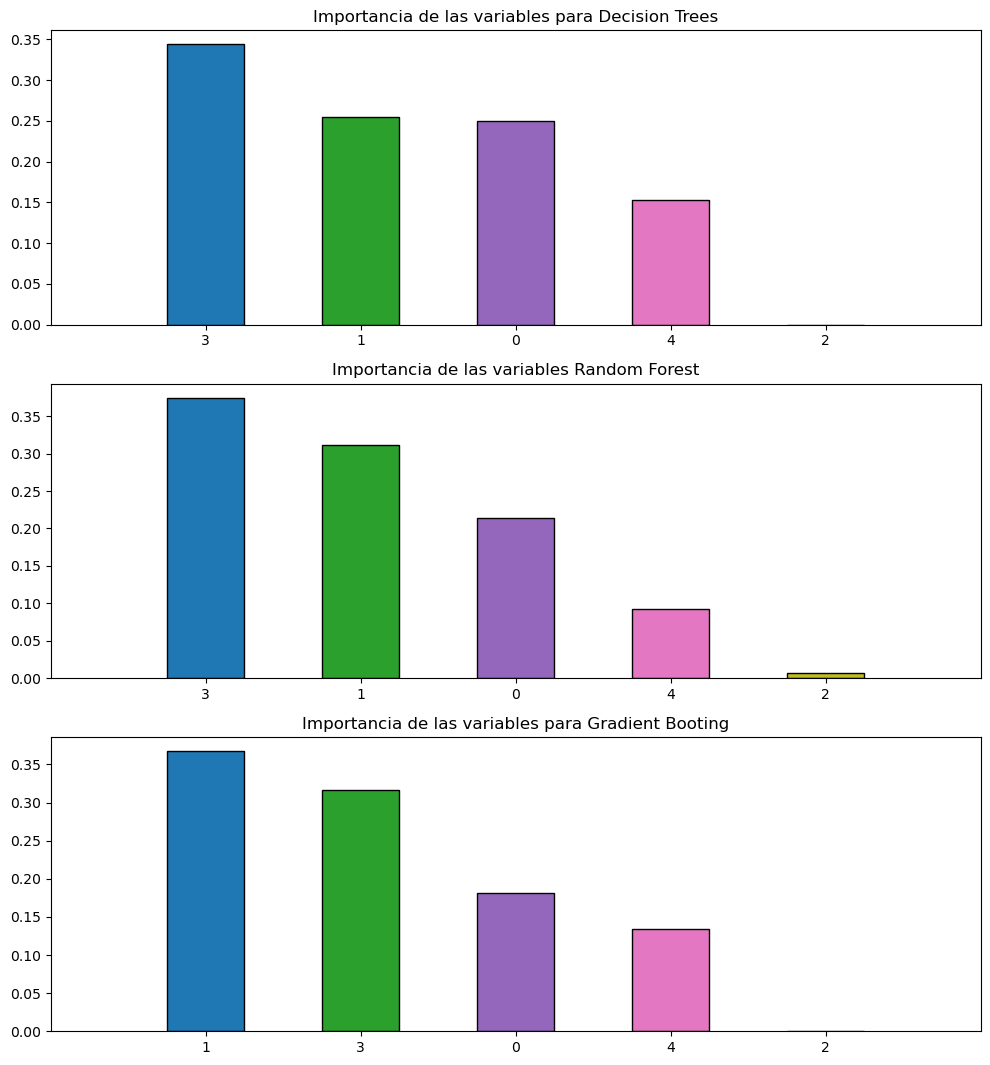

In [62]:
mt_ft = model_tree1.feature_importances_
rf_ft = model_tree_rf.feature_importances_
gd_ft = model_tree_gd.feature_importances_

mt_index = np.argsort(mt_ft)[::-1]
rf_index = np.argsort(rf_ft)[::-1]
gd_index = np.argsort(gd_ft)[::-1]
plt.figure(figsize = (12, 13))

plt.subplot(3, 1, 1)
plt.title("Importancia de las variables para Decision Trees")
plt.bar(range(X.shape[1]), mt_ft[mt_index],
        color=colors, align="center", edgecolor='black', width=0.5)
plt.xticks(range(X.shape[1]), mt_index)
plt.xlim([-1, X.shape[1]])

plt.subplot(3, 1, 2)
plt.title("Importancia de las variables Random Forest")
plt.bar(range(X.shape[1]), rf_ft[rf_index],
        color=colors, align="center", edgecolor='black', width=0.5)
plt.xticks(range(X.shape[1]), rf_index)
plt.xlim([-1, X.shape[1]])

plt.subplot(3, 1, 3)

plt.title("Importancia de las variables para Gradient Booting")
plt.bar(range(X.shape[1]), gd_ft[gd_index],
        color=colors, align="center", edgecolor='black', width=0.5)
plt.xticks(range(X.shape[1]), gd_index)
plt.xlim([-1, X.shape[1]])
# plt.tight_layout()

#### Observaciones

* Los modelos árboles de decisión y random forest otorgan la misma importancia de características, sin mucha variación en la magnitud de los valores de estos
* El atributo 3 (BP) es el más crítico para los modelos de árboles de decisión y random forest, seguido por el atributo 1 (Na_to_K) y en tercera posción la edad de los pacientes. 
* Para el modelo Gradient Boosting sin embargo, la característica más importante radica en Na_to_K, seguido de la presión sanguínea (BP), en tercera posición deja la edad (Age) y en cuarta posicón el nivel de Colésterol (Chol)
* La consistencia de la importancia de las características en los modelos sugiere que el conjunto de datos tiene una estructura coherente y los modelos concuerdan en qué características son más relevantes.
* Se puede considerar eliminar el atributo 2 (Sex) de los tres modelos ya que no contribuye al rendimiento de estos

### CONCLUSIONES
El objetivo de la actividad era resolver un problema de clasificación utilizando árboles de decisión y técnicas de ensemble, evaluar la importancia de las variables y comparar los resultados entre los modelos. El conjunto de datos, que predice el fármaco adecuado en función de las características del paciente, se preprocesó normalizando los datos numéricos y codificando las variables categóricas, ademas de uso de SMOTE para abordar el desbalance de clases. Los árboles de decisión lograron una precisión del 87,7%, mientras que los métodos de conjunto como Bagging y Pasting superaron este rendimiento con 92 y 93% para Bagging y Pasting respectivamente. Random Forest tuvo un rendimiento del 88,5 % debido a las restricciones de hiperparámetros (max_leaf_nodes = 4), mientras que Gradient Boosting se destacó con una precisión del 95,61%. El nivel de Sodio a Potacio (Na_to_K), la presión sanguínea (BP), la edad y el colésterol (Chol) fueron las características más importantes, mientras que el sexo tuvo un impacto mínimo. Se recomienda incluir el ajuste de hiperparámetros, la selección de características y la validación cruzada para mejorar aún más el rendimiento. 

### REFERENCIAS
* Dietterich, T. G. (2000). Ensemble methods in machine learning. In Multiple classifier systems (pp. 1–15). Springer.
https://www.cs.iastate.edu/~honavar/ensemble-learning.pdf

* Scikit-Learn. (n.d.). Ensemble methods. Scikit-Learn Documentation.
https://scikit-learn.org/stable/modules/ensemble.html

* Analytics Vidhya. (2020, April 15). Understanding feature importance in machine learning models.
https://www.analyticsvidhya.com/blog/2020/04/feature-scaling-machine-learning-normalization-standardization/